<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/05_cdnod_rcit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDNOD with RCIT on incremental delivery time

This notebook trains CDNOD on pooled multi-city delivery data using **RCIT** as the conditional independence test. The target is incremental delivery time, `incremental_duration`, computed as the signed delivery-time gap within each courier batch:

`incremental_duration_i = sign_time_i - sign_time_{i-1}`

Rows are sorted by `batch_id`, `sign_time`, and `batch_rank_actual`; first deliveries in a batch have no previous signed delivery and are excluded from the target model.

In [7]:
# Install dependencies only when running in a fresh notebook runtime.
# Local repo virtualenvs usually already contain causal-learn and pyarrow.
%pip install -q causal-learn pyarrow


Note: you may need to restart the kernel to use updated packages.


In [1]:
local = True

if not local:
    from google.colab import drive
    drive.mount('/content/drive')


In [3]:
from pathlib import Path
import inspect
import json
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from causallearn.search.ConstraintBased.CDNOD import cdnod
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

warnings.filterwarnings('ignore', category=RuntimeWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

if local:
    DATA_DIR = Path('data')
else:
    DATA_DIR = Path('/content/drive/MyDrive/ml/CORRECTEDv3')

CITY_ORDER = ['Shanghai', 'Hangzhou', 'Chongqing']
CITY_CODE = {city: i for i, city in enumerate(CITY_ORDER)}

DATA_PATHS = {
    'Chongqing': DATA_DIR / 'delivery_features_chongqing.parquet',
    'Shanghai': DATA_DIR / 'delivery_features_shanghai.parquet',
    'Hangzhou': DATA_DIR / 'delivery_features_hangzhou.parquet',
}

OUTPUT_DIR = DATA_DIR / 'causal_graphs' / 'cdnod_rcit'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('CDNOD signature:', inspect.signature(cdnod))
print('Data directory:', DATA_DIR.resolve() if DATA_DIR.exists() else DATA_DIR)
print('Output directory:', OUTPUT_DIR)


CDNOD signature: (data: numpy.ndarray, c_indx: numpy.ndarray, alpha: float = 0.05, indep_test: str = 'fisherz', stable: bool = True, uc_rule: int = 0, uc_priority: int = 2, mvcdnod: bool = False, correction_name: str = 'MV_Crtn_Fisher_Z', background_knowledge: causallearn.utils.PCUtils.BackgroundKnowledge.BackgroundKnowledge | None = None, verbose: bool = False, show_progress: bool = True, **kwargs) -> causallearn.graph.GraphClass.CausalGraph
Data directory: C:\Users\aymuo\Documents\Github\endgame\data
Output directory: data\causal_graphs\cdnod_rcit


## Delivery concepts

Each concept lists preferred feature columns in order. The preparation step chooses the first available column for each concept and appends `incremental_duration` as the target.

In [4]:
DELIVERY_CONCEPTS = {
    # Batch structure
    'batch_size': ['batch_size'],
    'spatial_isolation': ['isolated_delivery'],
    'local_clustering': ['same_aoi_share_in_batch'],
    'route_distance': ['pickup_destination_distance'],

    # Courier state before the delivery step
    'courier_efficiency': ['courier_eta_ewm'],
    'recent_speed': ['speed_mean_15m'],
    'recent_workload': ['distance_travelled_15m'],

    # Environment
    'weather_severity': ['WSI'],
    'demand_density': ['spatial_congestion_norm'],

    # Temporal
    'hour_cyclic': ['hour_sin'],
    'weekend_shift': ['is_weekend'],

    # POI / destination type
    'destination_type': ['typecode_cb'],

    # Incremental-time target
    'target': ['incremental_duration'],
}

TARGET = 'incremental_duration'
CONTEXT_VARIABLE = 'city_context'

# Domain constraints for the incremental-time target.
BLOCKED_TARGET_OUTGOING = [TARGET]
BLOCKED_INCOMING = [
    'hour', 'weekday', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos',
    'temperature_2m', 'precipitation', 'rain', 'weathercode', 'windspeed_10m', 'WSI',
]
FORBIDDEN_EDGE_SYNTAX = [
    (TARGET, 'batch_size'),
    (TARGET, 'isolated_delivery'),
    (TARGET, 'same_aoi_share_in_batch'),
    (TARGET, 'pickup_destination_distance'),
    (TARGET, 'courier_eta_ewm'),
    (TARGET, 'speed_mean_15m'),
    (TARGET, 'distance_travelled_15m'),
    (TARGET, 'WSI'),
    (TARGET, 'spatial_congestion_norm'),
    (TARGET, 'hour_sin'),
    (TARGET, 'is_weekend'),
    (TARGET, 'typecode_cb'),
]

# Run config
ALPHA = 0.01
N_BOOTSTRAPS = 20
STABILITY_THRESHOLD = 0.50
MAX_ROWS_PER_CITY = 300  # RCIT is numerically stable on this balanced sample
MIN_COMPLETE_ROWS = 100
DEFAULT_INDEP_TEST = 'rcit'

print(f'CI test: {DEFAULT_INDEP_TEST}')
print(f'Max rows per city: {MAX_ROWS_PER_CITY}')
print(f'Bootstraps: {N_BOOTSTRAPS}')


CI test: rcit
Max rows per city: 300
Bootstraps: 20


## Load data and construct incremental time

The target is created deterministically from timestamps, not read from a precomputed column. The notebook keeps both `delta_t_minutes` and `incremental_time_delta_t` aliases for auditability, while CDNOD uses `incremental_duration`.

In [5]:
def _first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_delivery_data(data_dir=DATA_DIR):
    combined = _first_existing([
        data_dir / 'all_cities_delivery_features_with_dynamic.parquet',
        data_dir / 'all_cities_delivery_features_v4.parquet',
        data_dir / 'all_cities_v4_filtered.parquet',
    ])
    if combined is not None:
        df = pd.read_parquet(combined)
        if 'city' in df.columns:
            return df, [combined]

    frames, paths = [], []
    for city in CITY_ORDER:
        path = DATA_PATHS[city]
        if not path.exists():
            fallback = data_dir / f'delivery_features_{city.lower()}.parquet'
            if fallback.exists():
                path = fallback
            else:
                raise FileNotFoundError(f'No delivery feature parquet found for {city}: {path}')
        part = pd.read_parquet(path)
        part['city'] = city
        frames.append(part)
        paths.append(path)

    return pd.concat(frames, ignore_index=True, sort=False), paths


def add_incremental_time(df):
    required = {'batch_id', 'sign_time'}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'Missing required columns for incremental time: {missing}')

    out = df.copy()
    out['sign_time'] = pd.to_datetime(out['sign_time'], errors='coerce')

    sort_cols = ['batch_id', 'sign_time']
    if 'batch_rank_actual' in out.columns:
        sort_cols.append('batch_rank_actual')
    if 'order_id' in out.columns:
        sort_cols.append('order_id')

    out = out.sort_values(sort_cols, kind='mergesort').reset_index(drop=True)
    group = out.groupby('batch_id', sort=False)
    out['previous_sign_time'] = group['sign_time'].shift(1)
    out['delta_t_minutes'] = (out['sign_time'] - out['previous_sign_time']).dt.total_seconds() / 60.0
    out['incremental_time_delta_t'] = out['delta_t_minutes']
    out['incremental_duration'] = out['delta_t_minutes']

    if 'delivery_index' not in out.columns:
        out['delivery_index'] = group.cumcount()

    invalid = out['incremental_duration'].notna() & (out['incremental_duration'] < 0)
    if invalid.any():
        raise ValueError(f'Found {int(invalid.sum())} negative incremental durations after sorting.')

    return out


raw_df, source_paths = load_delivery_data()
delivery_df = add_incremental_time(raw_df)

print('Raw shape:', raw_df.shape)
print('After delta_t construction:', delivery_df.shape)
print('Sources:', [str(p) for p in source_paths])
print('Rows with usable incremental_duration:', int(delivery_df[TARGET].notna().sum()))
print('Delta summary by city:')
display(delivery_df.dropna(subset=[TARGET]).groupby('city')[TARGET].describe())


Raw shape: (100163, 67)
After delta_t construction: (100163, 72)
Sources: ['data\\delivery_features_shanghai.parquet', 'data\\delivery_features_hangzhou.parquet', 'data\\delivery_features_chongqing.parquet']
Rows with usable incremental_duration: 78405
Delta summary by city:


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Chongqing,20209.0,52.965906,109.558459,5.0,9.0,18.0,46.0,1293.0
Hangzhou,31119.0,34.300074,79.398399,5.0,7.0,12.0,25.0,1269.0
Shanghai,27077.0,19.721350,59.066759,5.0,6.0,8.0,14.0,1429.0


In [6]:
def select_delivery_features(df, concepts=DELIVERY_CONCEPTS):
    selected, concept_map, missing = [], {}, {}
    for concept_name, feature_options in concepts.items():
        chosen = next((col for col in feature_options if col in df.columns), None)
        if chosen is None:
            missing[concept_name] = feature_options
            continue
        if chosen not in selected:
            selected.append(chosen)
        concept_map[concept_name] = chosen

    if TARGET not in selected:
        raise ValueError(f'{TARGET} was not selected. Check DELIVERY_CONCEPTS and delta_t construction.')

    return selected, concept_map, missing


def prepare_cdnod_data(df):
    selected, concept_map, missing = select_delivery_features(df)
    if 'city' not in df.columns:
        raise ValueError('DataFrame must contain city for CDNOD context.')

    model_df = df[selected + ['city', 'batch_id', 'order_id', 'sign_time', 'previous_sign_time']].copy()
    model_df = model_df.dropna(subset=selected + ['city']).copy()

    if MAX_ROWS_PER_CITY and MAX_ROWS_PER_CITY > 0:
        sampled = []
        for city in CITY_ORDER:
            city_df = model_df[model_df['city'] == city]
            if len(city_df) > MAX_ROWS_PER_CITY:
                city_df = city_df.sample(n=MAX_ROWS_PER_CITY, random_state=RANDOM_SEED)
            sampled.append(city_df)
        model_df = pd.concat(sampled, ignore_index=True)

    if len(model_df) < MIN_COMPLETE_ROWS:
        raise ValueError(f'Only {len(model_df)} complete rows available; need at least {MIN_COMPLETE_ROWS}.')

    scaler = StandardScaler()
    model_df[selected] = scaler.fit_transform(model_df[selected])

    X = model_df[selected].to_numpy(dtype=float)
    c_indx = model_df['city'].map(CITY_CODE).to_numpy(dtype=int)

    print('--- CDNOD data summary ---')
    print('Selected features:', selected)
    print('Concept map:', concept_map)
    if missing:
        print('Missing concepts:', missing)
    print('Model shape:', model_df.shape)
    print('City counts:', model_df['city'].value_counts().to_dict())

    return model_df, X, c_indx, selected, concept_map, missing


model_df, X, c_indx, variable_names, concept_map, missing_concepts = prepare_cdnod_data(delivery_df)


--- CDNOD data summary ---
Selected features: ['batch_size', 'isolated_delivery', 'same_aoi_share_in_batch', 'pickup_destination_distance', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'WSI', 'spatial_congestion_norm', 'hour_sin', 'is_weekend', 'typecode_cb', 'incremental_duration']
Concept map: {'batch_size': 'batch_size', 'spatial_isolation': 'isolated_delivery', 'local_clustering': 'same_aoi_share_in_batch', 'route_distance': 'pickup_destination_distance', 'courier_efficiency': 'courier_eta_ewm', 'recent_speed': 'speed_mean_15m', 'recent_workload': 'distance_travelled_15m', 'weather_severity': 'WSI', 'demand_density': 'spatial_congestion_norm', 'hour_cyclic': 'hour_sin', 'weekend_shift': 'is_weekend', 'destination_type': 'typecode_cb', 'target': 'incremental_duration'}
Model shape: (900, 18)
City counts: {'Shanghai': 300, 'Hangzhou': 300, 'Chongqing': 300}


## CDNOD with RCIT

`city` is supplied as CDNOD's context index and is not included as an ordinary feature in `X`. Background knowledge blocks operational features from causing the city context and blocks the incremental-time target from pointing back into its predictors.

In [7]:
def build_background_knowledge(variable_names):
    nodes = [GraphNode(f'node{i}') for i in range(len(variable_names) + 1)]
    city_idx = len(variable_names)
    variable_nodes = {name: nodes[i] for i, name in enumerate(variable_names)}
    variable_nodes[CONTEXT_VARIABLE] = nodes[city_idx]
    bk = BackgroundKnowledge()

    # Features and target cannot cause the city/regime context.
    for i in range(city_idx):
        bk.add_forbidden_by_node(nodes[i], nodes[city_idx])

    # Incremental duration is an outcome in this analysis.
    if TARGET in variable_names:
        target_node = variable_nodes[TARGET]
        for name, node in variable_nodes.items():
            if name not in {TARGET, CONTEXT_VARIABLE}:
                bk.add_forbidden_by_node(target_node, node)

    # Known exogenous/environmental/temporal inputs receive no incoming operational edges.
    for blocked in BLOCKED_INCOMING:
        if blocked in variable_nodes:
            blocked_node = variable_nodes[blocked]
            for name, node in variable_nodes.items():
                if name != blocked:
                    bk.add_forbidden_by_node(node, blocked_node)

    for src, dst in FORBIDDEN_EDGE_SYNTAX:
        if src in variable_nodes and dst in variable_nodes:
            bk.add_forbidden_by_node(variable_nodes[src], variable_nodes[dst])

    return bk


def run_cdnod_rcit(X, c_indx, variable_names, alpha=ALPHA, show_progress=True):
    X_stable = X + rng.normal(0, 1e-9, X.shape)
    requested = {
        'alpha': alpha,
        'indep_test': DEFAULT_INDEP_TEST,
        'stable': True,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': build_background_knowledge(variable_names),
    }
    supported = inspect.signature(cdnod).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported}
    return cdnod(X_stable, c_indx.reshape(-1, 1), **kwargs)


def graph_matrix(cg):
    graph_obj = getattr(cg, 'G', cg)
    matrix = getattr(graph_obj, 'graph', None)
    if matrix is None:
        raise AttributeError('Could not locate causal-learn graph matrix.')
    return np.asarray(matrix)


def endpoint_edge(matrix, i, j):
    a, b = int(matrix[i, j]), int(matrix[j, i])
    if a == 0 and b == 0:
        return None
    if a == -1 and b == 1:
        return 'i_to_j'
    if a == 1 and b == -1:
        return 'j_to_i'
    return 'ambiguous'


def extract_edges(cg, variable_names):
    matrix = graph_matrix(cg)
    names = list(variable_names)
    if matrix.shape[0] == len(names) + 1:
        names.append(CONTEXT_VARIABLE)

    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            kind = endpoint_edge(matrix, i, j)
            if kind == 'i_to_j':
                rows.append((names[i], names[j], 'directed'))
            elif kind == 'j_to_i':
                rows.append((names[j], names[i], 'directed'))
            elif kind == 'ambiguous':
                rows.append((names[i], names[j], 'ambiguous'))
    return pd.DataFrame(rows, columns=['source', 'target', 'edge_type']), names


In [8]:
def stratified_bootstrap_indices(city_labels, local_rng):
    idx = []
    city_labels = np.asarray(city_labels)
    for city in CITY_ORDER:
        city_idx = np.flatnonzero(city_labels == city)
        if len(city_idx):
            idx.extend(local_rng.choice(city_idx, size=len(city_idx), replace=True))
    return np.asarray(idx, dtype=int)


def bootstrap_cdnod_rcit(X, c_indx, city_labels, variable_names, n_bootstraps=N_BOOTSTRAPS):
    records = []
    successful = 0
    local_rng = np.random.default_rng(RANDOM_SEED)

    for b in range(n_bootstraps):
        idx = stratified_bootstrap_indices(city_labels, local_rng)
        try:
            cg_b = run_cdnod_rcit(X[idx], c_indx[idx], variable_names, show_progress=False)
            edges_b, _ = extract_edges(cg_b, variable_names)
            successful += 1
            for row in edges_b.itertuples(index=False):
                pair = tuple(sorted((row.source, row.target)))
                records.append({
                    'bootstrap': b,
                    'node_a': pair[0],
                    'node_b': pair[1],
                    'source': row.source,
                    'target': row.target,
                    'edge_type': row.edge_type,
                })
        except Exception as exc:
            print(f'Bootstrap {b} failed: {exc}')

        print(f'Completed {b + 1}/{n_bootstraps} bootstraps')

    rec = pd.DataFrame(records)
    if rec.empty:
        return pd.DataFrame(columns=['node_a', 'node_b', 'adjacency_stability', 'best_source', 'best_target', 'direction_stability'])

    completed = max(successful, 1)
    adjacency = (
        rec.groupby(['node_a', 'node_b'])['bootstrap']
        .nunique()
        .div(completed)
        .rename('adjacency_stability')
        .reset_index()
    )
    directed = rec[rec['edge_type'] == 'directed']
    if directed.empty:
        adjacency['best_source'] = None
        adjacency['best_target'] = None
        adjacency['direction_stability'] = 0.0
        return adjacency

    direction_counts = (
        directed.groupby(['node_a', 'node_b', 'source', 'target'])['bootstrap']
        .nunique()
        .rename('directed_count')
        .reset_index()
        .sort_values('directed_count', ascending=False)
        .drop_duplicates(['node_a', 'node_b'])
    )
    result = adjacency.merge(direction_counts, on=['node_a', 'node_b'], how='left')
    result['direction_stability'] = result['directed_count'].fillna(0) / completed
    return result.rename(columns={'source': 'best_source', 'target': 'best_target'}).drop(columns=['directed_count'])


def select_incremental_time_ancestors(stability, target=TARGET, threshold=STABILITY_THRESHOLD):
    stable = stability[stability['adjacency_stability'] >= threshold].copy()
    directed = stable[stable['best_source'].notna() & (stable['direction_stability'] >= threshold)].copy()

    G = nx.DiGraph()
    G.add_edges_from(directed[['best_source', 'best_target']].itertuples(index=False, name=None))

    parents = sorted(set(G.predecessors(target))) if target in G else []
    ambiguous = []
    for row in stable.itertuples(index=False):
        if target in {row.node_a, row.node_b} and row.direction_stability < threshold:
            ambiguous.append(row.node_b if row.node_a == target else row.node_a)

    kept = sorted(set(parents + [target]) - {CONTEXT_VARIABLE})
    return kept, parents, sorted(set(ambiguous)), directed


## Execute RCIT CDNOD

This cell runs the full-sample model and bootstrap stability. Reduce `N_BOOTSTRAPS` or `MAX_ROWS_PER_CITY` above for a quick smoke run.

In [9]:
print('Running full-sample CDNOD with RCIT...')
full_cg = run_cdnod_rcit(X, c_indx, variable_names, show_progress=True)
full_edges, graph_names = extract_edges(full_cg, variable_names)

print('Full-sample edges:')
display(full_edges.sort_values(['edge_type', 'source', 'target']).reset_index(drop=True))

print(f'Running {N_BOOTSTRAPS} stratified RCIT bootstraps...')
stability = bootstrap_cdnod_rcit(X, c_indx, model_df['city'].to_numpy(), variable_names)
stability = stability.sort_values(['adjacency_stability', 'direction_stability'], ascending=False).reset_index(drop=True)

kept, direct_parents, ambiguous_neighbors, stable_directed = select_incremental_time_ancestors(stability)

print('Stable direct parents of incremental duration:', direct_parents or 'none oriented')
print('Stable ambiguous target neighbors:', ambiguous_neighbors or 'none')
display(stability.head(20))


Running full-sample CDNOD with RCIT...


Depth=2, working on node 13: 100%|██████████| 14/14 [00:00<00:00, 18.02it/s]

Full-sample edges:


,source,target,edge_type
0,WSI,is_weekend,ambiguous
1,spatial_congestion_norm,hour_sin,ambiguous
2,batch_size,same_aoi_share_in_batch,directed
3,city_context,courier_eta_ewm,directed
4,city_context,typecode_cb,directed
5,courier_eta_ewm,batch_size,directed
6,isolated_delivery,batch_size,directed
7,isolated_delivery,same_aoi_share_in_batch,directed


Running 20 stratified RCIT bootstraps...


...

Depth=3, working on node 13: 100%|██████████| 14/14 [00:00<00:00, 71.61it/s]


Completed 19/20 bootstraps


Depth=2, working on node 13: 100%|██████████| 14/14 [00:03<00:00,  3.72it/s]

Completed 20/20 bootstraps
Stable direct parents of incremental duration: none oriented
Stable ambiguous target neighbors: none


,node_a,node_b,adjacency_stability,best_source,best_target,direction_stability
0,city_context,courier_eta_ewm,1.00,city_context,courier_eta_ewm,1.00
1,city_context,typecode_cb,1.00,city_context,typecode_cb,1.00
2,batch_size,same_aoi_share_in_batch,1.00,same_aoi_share_in_batch,batch_size,0.95
3,hour_sin,spatial_congestion_norm,1.00,hour_sin,spatial_congestion_norm,0.05
4,isolated_delivery,same_aoi_share_in_batch,1.00,same_aoi_share_in_batch,isolated_delivery,0.05
5,batch_size,spatial_congestion_norm,0.80,spatial_congestion_norm,batch_size,0.80
6,courier_eta_ewm,pickup_destination_distance,0.70,courier_eta_ewm,pickup_destination_distance,0.40
7,WSI,is_weekend,0.70,is_weekend,WSI,0.10
8,batch_size,hour_sin,0.30,hour_sin,batch_size,0.30
9,isolated_delivery,typecode_cb,0.30,isolated_delivery,typecode_cb,0.30


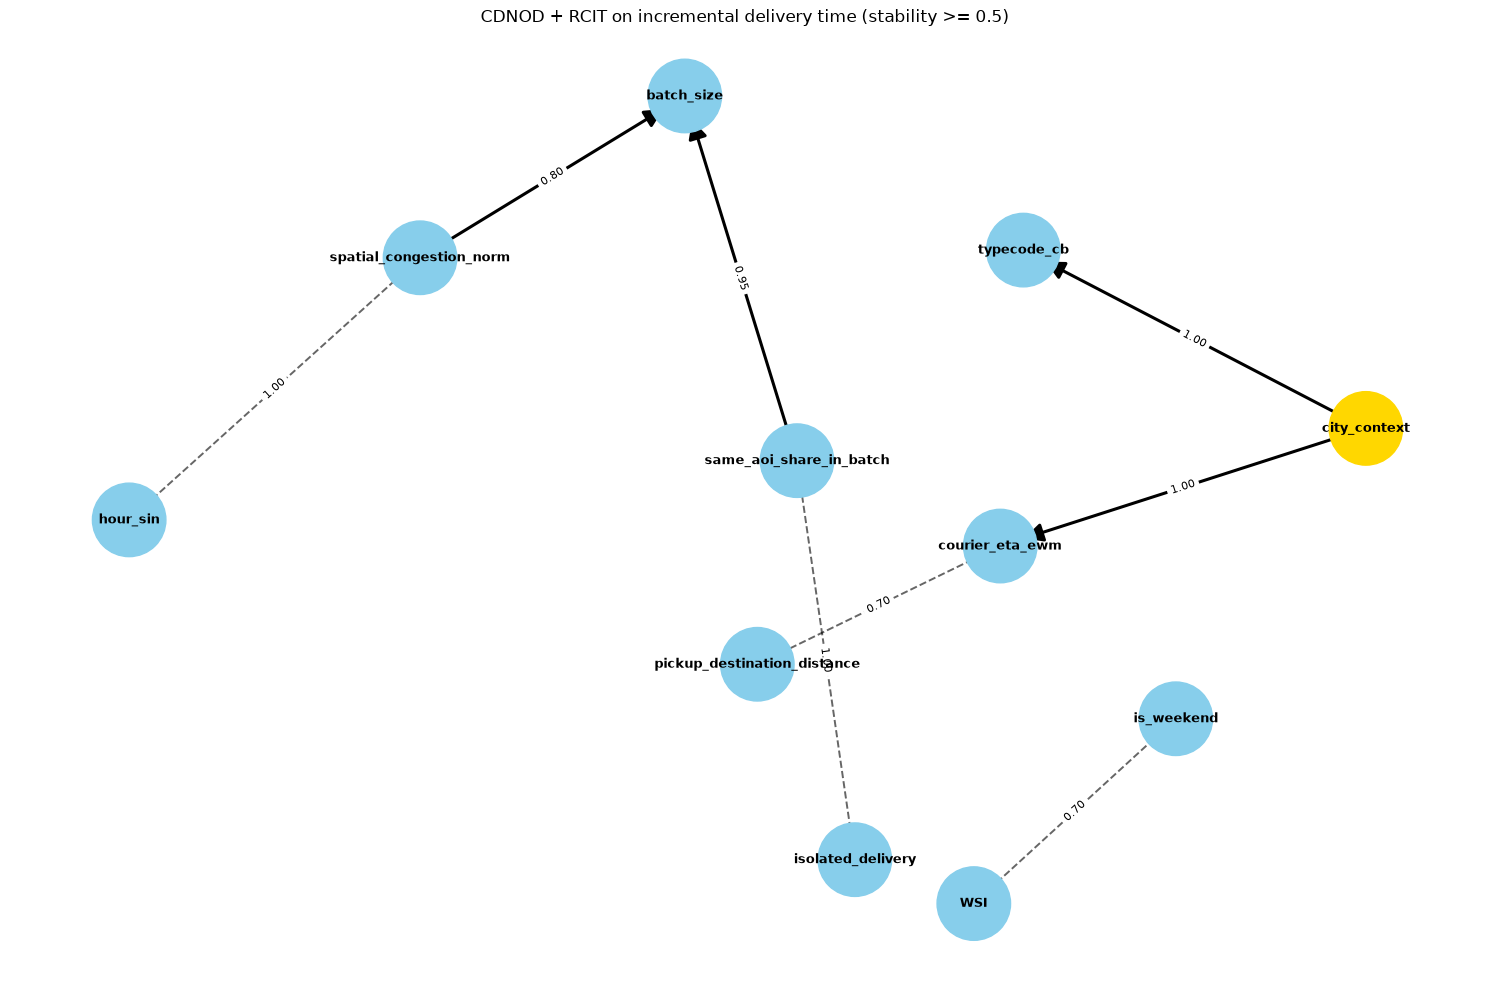

Saved figure: data\causal_graphs\cdnod_rcit\delivery_incremental_time_cdnod_rcit_graph.png


In [10]:
def plot_rcit_cdnod_graph(stability, threshold=STABILITY_THRESHOLD):
    stable = stability[stability['adjacency_stability'] >= threshold].copy()
    G = nx.DiGraph()
    for row in stable.itertuples(index=False):
        if row.best_source and row.direction_stability >= threshold:
            G.add_edge(row.best_source, row.best_target, weight=row.direction_stability, edge_type='directed')
        else:
            G.add_edge(row.node_a, row.node_b, weight=row.adjacency_stability, edge_type='ambiguous')

    if not G.nodes:
        print('No stable edges to plot.')
        return

    plt.figure(figsize=(15, 10))
    pos = nx.kamada_kawai_layout(G)
    node_colors = [
        'tomato' if n == TARGET else ('gold' if n == CONTEXT_VARIABLE else 'skyblue')
        for n in G.nodes
    ]
    directed_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'directed']
    ambiguous_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'ambiguous']

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2800)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edgelist=directed_edges, width=2.2, arrowsize=28, min_source_margin=18, min_target_margin=18)
    nx.draw_networkx_edges(G, pos, edgelist=ambiguous_edges, width=1.4, style='dashed', alpha=0.6, arrows=False)
    labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
    plt.title(f'CDNOD + RCIT on incremental delivery time (stability >= {threshold})')
    plt.axis('off')
    plt.tight_layout()

    out_path = OUTPUT_DIR / 'delivery_incremental_time_cdnod_rcit_graph.png'
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved figure:', out_path)


plot_rcit_cdnod_graph(stability)


In [11]:
# Save auditable outputs.
full_edges_path = OUTPUT_DIR / 'delivery_incremental_time_cdnod_rcit_full_edges.csv'
stability_path = OUTPUT_DIR / 'delivery_incremental_time_cdnod_rcit_edge_stability.csv'
reduced_path = OUTPUT_DIR / 'delivery_incremental_time_cdnod_rcit_ancestors.parquet'
metadata_path = OUTPUT_DIR / 'delivery_incremental_time_cdnod_rcit_metadata.json'

full_edges.to_csv(full_edges_path, index=False)
stability.to_csv(stability_path, index=False)
model_df[['city'] + kept].to_parquet(reduced_path, index=False)

metadata = {
    'target': TARGET,
    'incremental_time_formula': 'sign_time_i - sign_time_{i-1}, sorted within batch_id by sign_time, batch_rank_actual, order_id',
    'ci_test': DEFAULT_INDEP_TEST,
    'alpha': ALPHA,
    'n_bootstraps': N_BOOTSTRAPS,
    'stability_threshold': STABILITY_THRESHOLD,
    'max_rows_per_city': MAX_ROWS_PER_CITY,
    'city_order': CITY_ORDER,
    'city_code': CITY_CODE,
    'selected_features': variable_names,
    'delivery_concepts': DELIVERY_CONCEPTS,
    'concept_map': concept_map,
    'missing_concepts': missing_concepts,
    'direct_parents': direct_parents,
    'ambiguous_neighbors': ambiguous_neighbors,
    'kept_columns': kept,
    'city_counts': model_df['city'].value_counts().to_dict(),
    'input_paths': [str(p) for p in source_paths],
}
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved:', full_edges_path)
print('Saved:', stability_path)
print('Saved:', reduced_path)
print('Saved:', metadata_path)


Saved: data\causal_graphs\cdnod_rcit\delivery_incremental_time_cdnod_rcit_full_edges.csv
Saved: data\causal_graphs\cdnod_rcit\delivery_incremental_time_cdnod_rcit_edge_stability.csv
Saved: data\causal_graphs\cdnod_rcit\delivery_incremental_time_cdnod_rcit_ancestors.parquet
Saved: data\causal_graphs\cdnod_rcit\delivery_incremental_time_cdnod_rcit_metadata.json


## Interpretation checklist

- Use `direct_parents` as the most conservative oriented causes of incremental delivery time.
- Treat dashed/ambiguous target neighbors as structurally relevant but unoriented under the current threshold.
- `city_context` edges indicate city-heterogeneous mechanisms discovered by CDNOD.

In [ ]:
Key takeaways from the causal analysis and feature setup:

- No stable direct causes of `incremental_duration` were identified at the chosen stability threshold (`0.5`). That means, within this selected feature set and sampling regime, the model could not reliably orient any predictor as a causal parent of incremental delivery time.

- The strongest stable oriented relationships are:
    - `city_context -> courier_eta_ewm`
    - `city_context -> typecode_cb`
    This indicates strong city-specific regime effects on courier efficiency estimates and destination-type distributions.

- Batch structure is causally linked to spatial patterns:
    - `batch_size -> same_aoi_share_in_batch`
    - `batch_size -> spatial_congestion_norm`
    So larger batches appear consistently associated with more local clustering and higher congestion.

- The causal graph includes some ambiguous or weak links involving `incremental_duration`, e.g. with `batch_size`, `courier_eta_ewm`, `typecode_cb`, and `city_context`, but they did not reach stable orientation. That points to structural relevance without confident directionality.

- The final feature mapping preserves the intended delivery concepts:
    - batch / route: `batch_size`, `isolated_delivery`, `same_aoi_share_in_batch`, `pickup_destination_distance`
    - courier state: `courier_eta_ewm`, `speed_mean_15m`, `distance_travelled_15m`
    - environment: `WSI`, `spatial_congestion_norm`
    - temporal / category: `hour_sin`, `is_weekend`, `typecode_cb`

- The data pipeline ended up with a balanced sample of 300 rows per city for the causal analysis, which is moderate but may limit power for orienting weak causal links.

Implications:
- City heterogeneity is a dominant structural factor in this dataset.
- Batch composition and congestion appear structurally linked, so batch-level planning may be key for operational interventions.
- Incremental delivery time may require richer dynamic features or larger samples to identify stable causal parents.